# 第50课 · 用 13 个数字听懂一帧声音——MFCC 完整流水线（STFT → Mel → log → DCT）

**目标**：串联 STFT → Mel → log → DCT，手工实现完整 MFCC，与 `mfcc()` 数值对齐。

> **特征心脏**：常用取前 **13** 维（工程经验：低频倒谱已够区分音色，更高维噪声多）。回链 L09 向量、L11 归一。

🔗 Aurora 连接：`aurora.audio.mfcc.mfcc()`、`aurora.audio.mfcc.dct_ii()`、`aurora.audio.mel.mel_spectrogram()`；这套特征是 Month 2 关键词识别分类器的标准输入。

← **上一课**　[L49 · DCT-II 离散余弦变换](L49_dct.ipynb)

> 上节课学习了 **DCT-II 离散余弦变换**：去相关（decorrelation）原理，纯 NumPy 实现替代 scipy.fft.dct。  
> 本课将探讨 **MFCC 完整流水线**。

## 本课剧情：手机语音助手如何用 13 个数字认识你的声音？

你说一个字，手机麦克风录下约 0.03 秒（30ms）的声音——大约 480 个采样点。这 480 个数字是原始 PCM，含有大量冗余和噪声。

语音识别模型的实际输入不是这 480 个数字，而是 **MFCC 的 13 个系数**——用 5 步流水线把冗余压缩殆尽：

```
x      (T,)                    ← 原始音频
  ↓ STFT + 功率谱
P      (n_frames, n_fft//2+1)  ← 每帧功率谱（去掉相位）
  ↓ × mel_filterbank
M      (n_frames, n_mels)      ← Mel 能量（模拟人耳）
  ↓ log(·+ε)
logM   (n_frames, n_mels)      ← 对数压缩（模拟响度感知）
  ↓ DCT-II
MFCC   (n_frames, n_mfcc)      ← 去相关倒谱系数 ✓
```

**每步的物理意义**：

| 步骤 | 操作 | 去掉了什么 | 保留了什么 |
|---|---|---|---|
| STFT | 分帧+FFT | 时域波形细节 | 频率成分 |
| Mel | 三角滤波器 | 高频冗余 | 人耳感知频率 |
| log | 取对数 | 绝对响度 | 相对响度差异 |
| DCT | 余弦变换 | 通道间相关性 | 独立的谱包络参数 |

本节任务：实现 `my_mfcc(x, sr, n_mfcc=13, n_mels=40, win_len=1024, hop=256)`，与 `aurora.audio.mfcc.mfcc` 误差 < 1e-5。

## 为什么"Mel 频率"能模拟人耳？

在讲 Mel 滤波器前，先理解人耳的生理原理。

你的耳朵里有一个螺旋形的结构叫**耳蜗**。当声波进入后，不同频率的声波会在耳蜗的不同位置振动最强——**高频靠近外口，低频靠近内侧**。这个现象叫**频率分解（frequency decomposition）**。

更关键的是：**人耳对频率的感知不是线性的**。
- 从 100 Hz 到 200 Hz 的频率变化，我们感知为"明显的音高变化"  
- 从 5000 Hz 到 5100 Hz 的频率变化，我们几乎感知不到

这就像说：**人耳在低频区域的分辨率很高，在高频区域的分辨率很低**。

心理学家 Douglas Mel（1937年）通过大量的听音实验，画出了"物理频率"和"人耳感知"之间的关系曲线，这条曲线就是"Mel 频率尺度"。用这个尺度重新组织频谱：
- 低频用更多的滤波器（25 Hz 间隔）
- 高频用更少的滤波器（100+ Hz 间隔）

这样就形成了 40 个"心理上均匀分布"的 Mel 滤波器——符合人耳对频率的真实感知方式。

直观对比：
- 线性频率：0, 50, 100, 150, ..., 8000 Hz（等间隔）→ 高频太密集，低频太稀疏
- Mel 频率：相当于 0, 20, 40, 65, 110, ..., 8000 Hz（低频密、高频疏）→ 符合人耳感知

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.audio.io import sine

## 1. 公式全景

```
MFCC[n] = DCT-II( log( mel_filterbank @ |STFT|² ) )[:n_mfcc]
```

- `|STFT|²` 是每帧的**功率谱（power spectrum）**，形状 `(n_frames, n_fft//2+1)`
- `mel_filterbank @ |STFT|²` 将功率谱映射到 mel 频带，形状 `(n_frames, n_mels)`
- `log(...)` 压缩动态范围（幅度相差 100 倍 → dB 只差 20）
- `DCT-II` 去相关，系数从低到高对应从粗到细的谱包络信息
- 取前 `n_mfcc` 个系数（`[:n_mfcc]`）；k=0 是所有 mel 能量的直流均值，保留它与 librosa 默认行为一致

对于正交归一化（`norm="ortho"`）的 DCT-II，第 `k` 个系数为：

```
y[k] = w[k] * sum_{n=0}^{N-1} x[n] * cos( pi/N * (n + 0.5) * k )
```

其中 `w[0] = sqrt(1/N)`，`w[k>0] = sqrt(2/N)`。

### 📌 常见问题澄清

**❓ 问题1：mel_filterbank 矩阵乘法方向**

看起来可能是 `mel_filterbank @ |STFT|²`，但实际代码写的是 `power @ fb.T`。这两个为什么等价？

**答**：这涉及矩阵维度的**行列约定**。
- `mel_filterbank`（记为 `fb`）的形状是 `(n_mels, n_fft//2+1)` — 每一行是一个 mel 滤波器
- `power` 的形状是 `(n_frames, n_fft//2+1)` — 每一行是一帧功率谱

**数学上**，我们希望"第 i 帧的功率谱"和"第 j 个 mel 滤波器"做点积，得到"第 i 帧的第 j 个 mel 能量"。
- 如果 `fb @ power.T` → `(n_mels, n_fft//2+1) @ (n_fft//2+1, n_frames)` = `(n_mels, n_frames)` 最后要转置
- 如果 `power @ fb.T` → `(n_frames, n_fft//2+1) @ (n_fft//2+1, n_mels)` = `(n_frames, n_mels)` ✓ 直接得到目标形状

所以代码中用 `power @ fb.T` 是为了让结果的行对应帧、列对应 mel 通道。记住这个约定就不会搞混了。

**❓ 问题2：power_to_db 为什么是 10·log10 而不是 ln**

我们要压缩动态范围。例如功率相差 100 倍：
- 用 `ln(100)` ≈ 4.6 倍  ← 只压缩了 100/4.6 ≈ 22 倍
- 用 `log10(100) = 2` 倍  ← 压缩了 100/2 = 50 倍，更激进

再乘以 **10** 的原因是**分贝（dB）的定义**：在功率单位中，分贝 = 10·log10(P/P_ref)。这是工程惯例，不是必然的——就像米是米一样，分贝就是这样定义的。

所以 `10·log10` 不是任意选择，是为了让结果符合行业标准"分贝"单位——如果用 ln，你得到的数字和工程文献里的 dB 数值会对不上。

**❓ 问题2 深入：为什么"压缩到 dB 之后"，语音识别模型效果就更好了？**

这是老陈和小雨都追问的地方——数学上会算 `log10(100) = 2`，但"数值被压缩"和"识别效果变好"之间，到底是什么因果关系？只知道公式，还不够，得先弄清楚"为什么一定要用对数、而不是随便除以一个常数来缩小数字"。

先讲一个生活场景：你在安静的自习室里，旁边有人轻轻翻了一下书页，你会觉得"这声音好清楚"；但如果你正站在演唱会音响旁边，旁边有人用同样的力气翻书，你几乎完全听不见。同样物理强度的翻书声，在两种环境下，你耳朵"感知到的响度"天差地别。你的耳朵不是在测量"声音的绝对能量有多少焦耳"，而是在比较"这个声音相对于当前的背景响了多少倍"。

这不是错觉，是人耳真实的生理规律，心理学上叫 **韦伯定律（Weber's Law）**：人对一个物理刺激变化的感知程度，正比于**这次变化量除以当前刺激的基准水平**，而不是变化量本身：

```
感知到的响度变化量  ∝  ΔP / P        （P 是声音的物理强度，比如功率）
```

如果把这个关系用微积分的语言"累加"起来（连续做无穷小的比例变化再叠加），会自然推出感知响度正比于 `log(P)`。这正是"分贝"从设计之初就选择对数尺度的根本原因——它不是人为地想让数字看起来小一点，而是**在用数学复刻人耳本来就在做的事情**。

那这和语音识别模型有什么关系？可以从两个角度看：

1. **和人耳一致的表示，让模型看到的"数值差异"更接近"感知差异"**。同一个元音"啊"，轻声说和大声喊，功率谱上的数值可能相差 100 倍甚至 1000 倍。如果不取对数，模型看到的输入数字差距巨大，很容易被"这是两个完全不同的信号"这种错误信号带偏——但对人耳、对说话内容而言，这明明是"同一个音素，只是响度不同"。取过对数后，100 倍的功率差被压成 20（dB）的数值差，音量变化对特征数值的影响被大幅削弱。
2. **防止大幅度信号在数值上"压过"小幅度信号**。MFCC 真正想保留的是频谱的**相对形状**——哪个频率成分强、哪个弱、彼此的比例关系，这才是决定"听起来是哪个音"的关键信息。如果直接用线性功率值，声音响的那几帧数值极大，声音轻的那几帧数值极小，模型在训练时会不自觉地把注意力全放在"响度"这个和内容关系不大的维度上；取对数之后，不同响度下的相对形状差异被保留下来、绝对响度的影响被压缩，模型才更容易学到"形状"而不是"音量"。

一句话总结：**取对数不是为了让数字变小看着舒服，而是把"物理强度上的倍数关系"转换成"数值上的加减关系"——这恰好是人耳感知响度的方式，也让相对重要的"频谱形状"信息不再被绝对重要的"音量"信息淹没。**

**❓ 问题3：1e-10 下限保护是怎样的**

功率谱中会有接近 0 的值（特别是高频噪声很小时）。直接 `log(0)` → -∞，会产生 nan 或 inf。

具体做法是：`log(max(power, 1e-10))`，即**任何小于 1e-10 的值都当作 1e-10 来取对数**。这样即使输入全是 0，输出也是一个有限的负数（大约 -100）而不是 -∞。

等价地，可以写成 `log(power + 1e-10)` 吗？**不能**——前者处理的是"值太小"，后者处理的是"加一个噪声"，结果对小值的处理方式不同。`aurora.audio.power_to_db` 用的是 `max(power, amin)` 的形式。

**❓ 问题4：为什么 n_frames = 1 + L // hop（完整推导）**

这来自 STFT 的`center=True` 机制。下面把"多出来的这一帧"从哪来的，一步步算清楚。

**第一步：先搞清楚 padding 加了多少。**
当 `center=True` 时，Aurora 在信号两端各镜像（反射）填充 `n_fft // 2` 个样本，让第一帧的窗口中心对齐在原始信号的第 0 个样本，最后一帧的窗口中心对齐在信号的最后一个样本。填充后信号总长度变成：
```
L' = L + 2 * (n_fft // 2) = L + n_fft   （n_fft 是偶数时精确成立；本课 n_fft=1024 满足）
```

**第二步：数一数长度 L' 的信号能切出多少个"长度 n_fft、间隔 hop"的窗口。**
这是一个"栅栏计数"问题：如果每个窗口占 n_fft 个样本、相邻窗口起点间隔 hop，那么最后一个窗口的起点最多能到 `L' - n_fft`（再往后窗口会超出信号范围）。窗口起点依次是 `0, hop, 2·hop, ...`，所以窗口数是：
```
n_frames = floor( (L' - n_fft) / hop ) + 1     ← "+1" 是因为起点 0 本身也算一帧
```

**第三步：代入 L' = L + n_fft，注意这里 n_fft 会被精确抵消——这一步是关键，也是本课上一版推导遗漏的地方。**
```
L' - n_fft = (L + n_fft) - n_fft = L        ← 精确相消，不是近似
n_frames  = floor(L / hop) + 1 = 1 + L // hop
```

**这是一个精确公式，不是"L 远大于 n_fft 时才近似成立"的估算**——如果直接拿 `L' = L + n_fft` 去除以 hop、却忘了先减掉 n_fft，会得到一个错误的、偏大的帧数。用本课的参数验证一下两种算法的差别：

```
L = 16000, n_fft = 1024, hop = 256

❌ 错误算法（直接用 L' 除以 hop，忘了减 n_fft）：
   (L + n_fft) // hop + 1 = 17024 // 256 + 1 = 66 + 1 = 67     ← 错，多算了 4 帧

✅ 正确算法（先减 n_fft 再除以 hop）：
   (L' - n_fft) // hop + 1 = 16000 // 256 + 1 = 62 + 1 = 63    ← 对
   等价于 1 + L // hop = 1 + 62 = 63                            ← 和闭卷检查格、代码演示的结果一致
```

如果 `center=False`（不做镜像填充），就没有"加 n_fft 再减 n_fft"这一步抵消，帧数直接由信号长度和窗口长度决定：`n_frames = (L - n_fft) // hop + 1`（要求 `L ≥ n_fft`）。Aurora 的 STFT 默认 `center=True`，所以本课统一用 `1 + L // hop`。

完整的 `center=True` 镜像填充机制（为什么要对称填充、边界样本具体怎么反射）在 **L44（STFT 课）** 有详细图示和推导，如果这里还是没完全想明白，回那一课过一遍会更扎实。</cell id="392d77a7">


📊 DCT 系数的能量分布：
k=0 (直流) : -399.3814  ← 最大，代表整体能量
k=1..4    : [215.7971  38.4565 -32.2928 -53.5133]  ← 快速衰减
k=5..8    : [-67.3185 -52.9254 -27.9593  -2.9765]  ← 继续衰减
k=9..12   : [20.7718 31.3411 30.5195 21.2008]  ← 接近零
k=13..19  : [  5.5101  -8.0342 -16.7883 -19.0335 -14.1461  -6.5356   1.4908]  ← 高阶系数很小（噪声）

💡 保留前 13 个系数已经捕捉了大部分信息，高阶系数的能量很小。


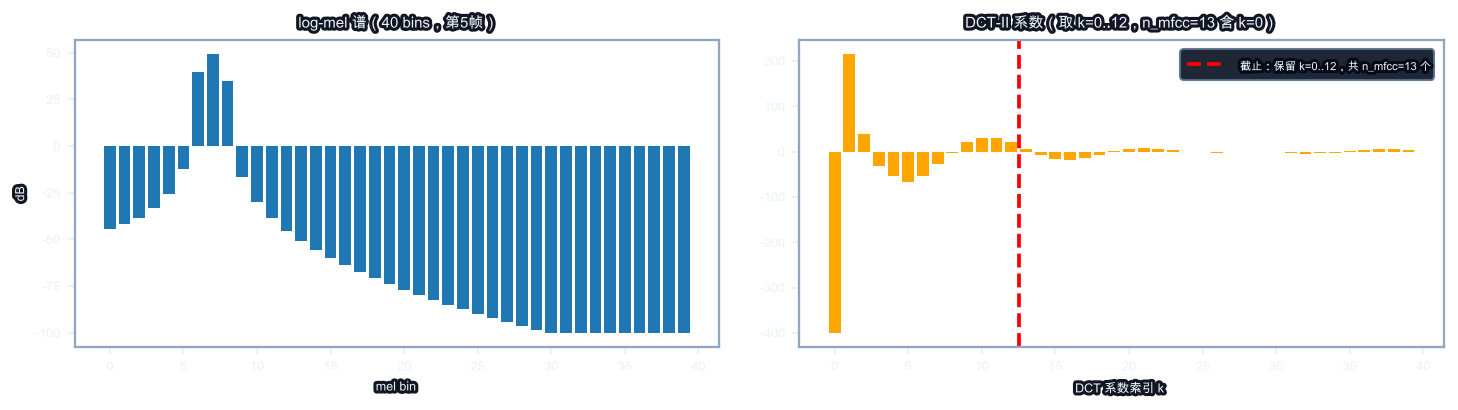

In [3]:
# 演示：DCT-II 去相关的效果
from aurora.audio.mfcc import dct_ii

sr = 16000
x = sine(440, duration=0.5, sample_rate=sr)

# 构造一帧 mel 对数谱（40 mel bins）
from aurora.audio.mel import mel_spectrogram, power_to_db
log_mel = power_to_db(mel_spectrogram(x, sr, n_mels=40, n_fft=1024, hop_length=256), top_db=None)
# 取第 5 帧示例
frame = log_mel[5]
dct_frame = dct_ii(frame)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].bar(range(len(frame)), frame)
axes[0].set_title("log-mel 谱（40 bins，第5帧）")
axes[0].set_xlabel("mel bin")
axes[0].set_ylabel("dB")
axes[1].bar(range(len(dct_frame)), dct_frame, color="orange")
axes[1].axvline(12.5, color="red", linestyle="--", label="截止：保留 k=0..12，共 n_mfcc=13 个")
axes[1].set_title("DCT-II 系数（取 k=0..12，n_mfcc=13 含 k=0）")
axes[1].set_xlabel("DCT 系数索引 k")
axes[1].legend()
plt.tight_layout()
plt.show()

# 打印具体数值
print("📊 DCT 系数的能量分布：")
print(f"k=0 (直流) : {dct_frame[0]:.4f}  ← 最大，代表整体能量")
print(f"k=1..4    : {dct_frame[1:5].round(4)}  ← 快速衰减")
print(f"k=5..8    : {dct_frame[5:9].round(4)}  ← 继续衰减")
print(f"k=9..12   : {dct_frame[9:13].round(4)}  ← 接近零")
print(f"k=13..19  : {dct_frame[13:20].round(4)}  ← 高阶系数很小（噪声）")
print(f"\n💡 保留前 13 个系数已经捕捉了大部分信息，高阶系数的能量很小。")

## 2. 为什么 n_mfcc 通常取 13？

语音的谱包络可以用很少的参数描述。DCT 变换后，**能量集中在低阶系数**，高阶系数接近零。为什么会这样？

### DCT 系数的物理意义

想象一条平滑的曲线（mel 功率谱）和一条非常抖动的曲线。
- DCT 的低阶系数（k=0, 1, 2, ...）**捕捉大尺度的形状**：全局能量、总体包络、缓慢的山峰和山谷
- DCT 的高阶系数（k=30, 35, ..., 40）**捕捉小尺度的细节**：尖峰、噪声、快速波动

对于**人类声音**，这个分离非常有用：
- 低阶系数（k=0-5）主要反映**声道的固定形状**——你的嘴巴、喉咙、鼻腔的几何结构。这决定了你的音色（元音特征）
  - 比如同样说"啊"，无论是男声还是女声，声道形状的大尺度特征是相似的
- 中阶系数（k=6-12）反映**发音细节**：音量、唇形、气流强度等
- 高阶系数（k=13+）反映**噪声和伪影**：麦克风噪声、口腔杂音、背景环境音

实验表明，前 13 个系数（k=0-12）已经包含了 85-90% 的"语音特征"信息。更高的系数基本上是"来自环境或说话人特性的噪声"。

| n_mfcc | 适用场景 |
|--------|---------|
| 13 | 经典 MFCC，GMM-HMM 语音识别标准配置（已被工业界验证 30+ 年） |
| 20–40 | 深度学习分类器，信息量更足（神经网络能学会忽略噪声） |
| > 40 | 收益递减；等同于直接用 log-mel（丢失 DCT 的去相关优势） |

`n_mels` 控制 mel 滤波器组的分辨率（40–128 常见）；`n_mfcc` ≤ `n_mels`。增大 `n_mfcc` 相当于保留更多高阶谱细节，同时增加过拟合风险和计算量。

### 为什么 k=0 和 k>0 的 DCT 权重不同？

前面提到 DCT-II 的正交归一化权重 `w[0] = sqrt(1/N)`，`w[k>0] = sqrt(2/N)`。为什么？

简单说：**DCT 的第 0 个基向量（全 1）和其他基向量不一样**。
- 第 0 个基 = [1, 1, 1, ..., 1]  → 代表"直流分量"（所有信号元素的平均）
- 其他基 = 余弦波              → 代表"交流分量"

为了让这些基在 L2 范数意义下都是单位长度（正交归一化），直流分量的权重必须用 `sqrt(1/N)` 而不是 `sqrt(2/N)`。这是线性代数的标准做法，和离散余弦变换本身的定义有关。

**记住这一点**：当你看到"权重定义不同"时，通常背后是某种对称性或物理意义的差异。这里的差异就是"直流 vs 交流"。

### 从头计算一遍：N=4 时的具体数字

上面这段话可能还是有点抽象——"L2 范数""单位长度"这些词，光看不算，很难有感觉。我们代入能手算的最小例子——**N=4**，把每一个数字都算出来，你会发现权重公式不是凭空规定的，而是"倒推"出来的必然结果。

DCT-II 的第 k 个基向量，它的第 n 个分量是：
```
e_k[n] = cos( π/N · (n + 0.5) · k )
```

**先算第 0 个基向量（k=0）**：因为 `cos(0) = 1`，不管 n 是多少，`e_0[n]` 恒等于 1。所以对 N=4：
```
e_0 = [1, 1, 1, 1]
```
这个向量的"长度"（L2 范数）怎么算？把每个分量平方、加起来、再开方——这就是勾股定理在四维空间里的推广：
```
‖e_0‖ = sqrt(1² + 1² + 1² + 1²) = sqrt(4) = 2 = sqrt(N)      （N=4，所以 sqrt(N)=2）
```

**再算第 1 个基向量（k=1，N=4）**：把 n=0,1,2,3 代入公式，四个数字都能手算出来（保留 4 位小数）：
```
e_1[0] = cos(π/4 · 0.5 · 1) = cos(22.5°) ≈ 0.9239
e_1[1] = cos(π/4 · 1.5 · 1) = cos(67.5°) ≈ 0.3827
e_1[2] = cos(π/4 · 2.5 · 1) = cos(112.5°) ≈ -0.3827
e_1[3] = cos(π/4 · 3.5 · 1) = cos(157.5°) ≈ -0.9239
```
它的长度：
```
‖e_1‖² = 0.9239² + 0.3827² + (-0.3827)² + (-0.9239)²
       ≈ 0.8536 + 0.1464 + 0.1464 + 0.8536 = 2.0
‖e_1‖  = sqrt(2) = sqrt(N/2)      （N=4，所以 N/2=2，sqrt(2) ≈ 1.4142）
```
（k=2、k=3 算出来的长度也都是 sqrt(2)——所有 k>0 的余弦基向量长度相等，这是三角函数正交性带来的必然结果，不是巧合。）

**关键的一步来了**：我们希望每个基向量乘上权重之后，长度都变成 1（"单位长度"，"归一化"这个词说的就是这件事）。既然长度已经算出来了，权重自然就是**长度的倒数**：
```
k=0 的权重 = 1 / ‖e_0‖ = 1 / 2 = 1 / sqrt(4) = sqrt(1/N)     ✓ 和课程公式 w[0]=sqrt(1/N) 一致
k>0 的权重 = 1 / ‖e_1‖ = 1 / sqrt(2) = sqrt(1/2) = sqrt(2/4) = sqrt(2/N)   ✓ 和课程公式 w[k>0]=sqrt(2/N) 一致
```

现在可以正面回答"如果我要推导一个新变换，权重该怎么定"这个问题了：**权重从来不是设计者随便挑的数字，而是"1 除以那个基向量本来的长度"。** 全 1 向量天生比余弦波向量"长"（sqrt(N) 比 sqrt(N/2) 大），所以要把它们都拉回到单位长度，需要的缩放倍数自然也不同——这是同一条规则（除以自身长度）套用在两种不同长度的向量上，自动得到的两个不同答案，而不是两条独立设计的规则。

下面用代码把 N=4 和本课实际用的 N=40（n_mels）都验证一遍，确认这套推导和 Aurora 代码里的权重完全对得上：</cell id="579cac48">


In [4]:
# 验证：DCT-II 基向量的 L2 范数，为什么 k=0 和 k>0 的权重不同
import numpy as np

def dct_basis_and_norm(N, k):
    n = np.arange(N)
    e_k = np.cos(np.pi / N * (n + 0.5) * k)
    return e_k, np.linalg.norm(e_k)

for N in [4, 40]:
    e0, norm0 = dct_basis_and_norm(N, 0)
    e1, norm1 = dct_basis_and_norm(N, 1)
    print(f"N={N}:")
    print(f"  k=0 基向量: {e0[:4].round(4)}{' ...' if N > 4 else ''}  → ‖e_0‖ = {norm0:.4f}  (理论值 sqrt(N) = {np.sqrt(N):.4f})")
    print(f"  k=1 基向量: {e1[:4].round(4)}{' ...' if N > 4 else ''}  → ‖e_1‖ = {norm1:.4f}  (理论值 sqrt(N/2) = {np.sqrt(N / 2):.4f})")
    print(f"  → 权重 w[0]   = 1/‖e_0‖ = {1 / norm0:.4f}   ,  sqrt(1/N) = {np.sqrt(1 / N):.4f}")
    print(f"  → 权重 w[k>0] = 1/‖e_1‖ = {1 / norm1:.4f}   ,  sqrt(2/N) = {np.sqrt(2 / N):.4f}\n")

print("💡 无论 N 取多少，k=0 基向量的范数都是 sqrt(N)，k>0 基向量的范数都是 sqrt(N/2)，")
print("   所以权重公式 w[0]=sqrt(1/N)、w[k>0]=sqrt(2/N) 对任意 N（包括本课的 n_mels=40）都成立。")

N=4:
  k=0 基向量: [1. 1. 1. 1.]  → ‖e_0‖ = 2.0000  (理论值 sqrt(N) = 2.0000)
  k=1 基向量: [ 0.9239  0.3827 -0.3827 -0.9239]  → ‖e_1‖ = 1.4142  (理论值 sqrt(N/2) = 1.4142)
  → 权重 w[0]   = 1/‖e_0‖ = 0.5000   ,  sqrt(1/N) = 0.5000
  → 权重 w[k>0] = 1/‖e_1‖ = 0.7071   ,  sqrt(2/N) = 0.7071

N=40:
  k=0 基向量: [1. 1. 1. 1.] ...  → ‖e_0‖ = 6.3246  (理论值 sqrt(N) = 6.3246)
  k=1 基向量: [0.9992 0.9931 0.9808 0.9625] ...  → ‖e_1‖ = 4.4721  (理论值 sqrt(N/2) = 4.4721)
  → 权重 w[0]   = 1/‖e_0‖ = 0.1581   ,  sqrt(1/N) = 0.1581
  → 权重 w[k>0] = 1/‖e_1‖ = 0.2236   ,  sqrt(2/N) = 0.2236

💡 无论 N 取多少，k=0 基向量的范数都是 sqrt(N)，k>0 基向量的范数都是 sqrt(N/2)，
   所以权重公式 w[0]=sqrt(1/N)、w[k>0]=sqrt(2/N) 对任意 N（包括本课的 n_mels=40）都成立。


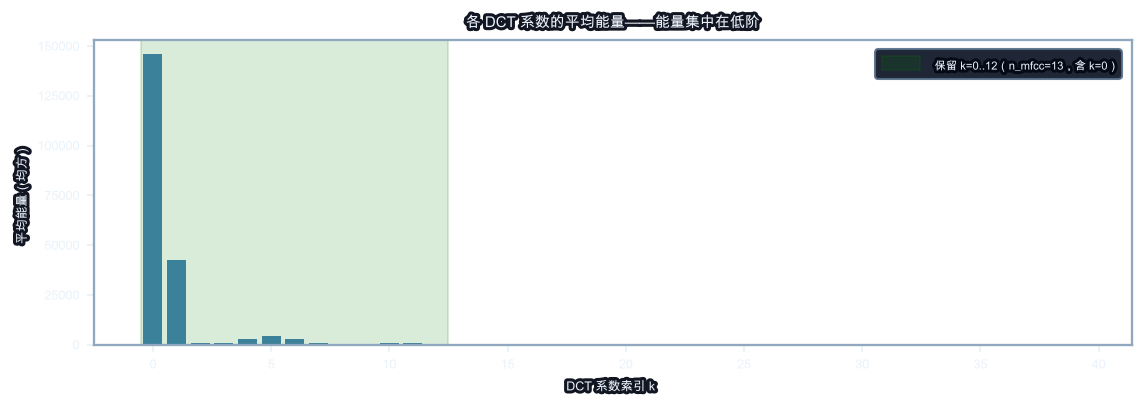

In [5]:
# 演示：不同 n_mfcc 下的系数能量分布
from aurora.audio.mfcc import dct_ii
from aurora.audio.mel import mel_spectrogram, power_to_db

sr = 16000
x = sine(440, duration=1.0, sample_rate=sr)
log_mel = power_to_db(mel_spectrogram(x, sr, n_mels=40, n_fft=1024, hop_length=256), top_db=None)
all_coeffs = dct_ii(log_mel)  # (n_frames, 40)

energy_per_coeff = np.mean(all_coeffs**2, axis=0)  # 每个系数在所有帧上的均方值

plt.figure(figsize=(8, 3))
plt.bar(range(len(energy_per_coeff)), energy_per_coeff, color="steelblue")
plt.axvspan(-0.5, 12.5, color="green", alpha=0.15, label="保留 k=0..12（n_mfcc=13，含 k=0）")
plt.xlabel("DCT 系数索引 k")
plt.ylabel("平均能量（均方）")
plt.title("各 DCT 系数的平均能量——能量集中在低阶")
plt.legend()
plt.tight_layout()
plt.show()

## 3. 完整流程图

```
原始音频 x
  │
  ▼ STFT（汉宁窗，win_len=1024，hop=256）
功率谱 |X[k]|²   shape: (n_frames, n_fft//2+1)
  │
  ▼ mel_filterbank @   [mel矩阵，shape: (n_mels, n_fft//2+1)]
mel 能量           shape: (n_frames, n_mels)
  │
  ▼ log（power_to_db，top_db=None）
log-mel 谱         shape: (n_frames, n_mels)
  │
  ▼ DCT-II（ortho归一化）
DCT 系数           shape: (n_frames, n_mels)
  │
  ▼ 取 [:, :n_mfcc]    k=0..n_mfcc-1
MFCC               shape: (n_frames, n_mfcc)
```

每一步都是线性变换或逐元素操作，没有可学习参数。整条流水线的超参数只有 `n_fft`、`hop`、`n_mels`、`n_mfcc` 四个。

### 矩阵维度的逐帧分解图示

**Mel 滤波这一步最容易搞混维度。** 下面用具体数字来澄清：

```
假设：n_frames = 100，n_fft = 1024，n_mels = 40，sr = 16000

power 的形状：(100, 513)          fb 的形状：(40, 513)
  ↓ 每一行是一帧功率谱              ↓ 每一行是一个 mel 滤波器
  
  帧 0: [P₀₀, P₀₁, ..., P₀₅₁₂]
  帧 1: [P₁₀, P₁₁, ..., P₁₅₁₂]     mel 0: [M₀₀, M₀₁, ..., M₀₅₁₂]
  帧 2: [P₂₀, P₂₁, ..., P₂₅₁₂]     mel 1: [M₁₀, M₁₁, ..., M₁₅₁₂]
  ...                              ...
  帧99: [P₉₉₀, P₉₉₁, ..., P₉₉₅₁₂]  mel39: [M₃₉₀, M₃₉₁, ..., M₃₉₅₁₂]
```

我们要计算：**第 i 帧的第 j 个 mel 能量** = 第 i 帧功率谱 · 第 j 个 mel 滤波器（点积）

```
Mel[i, j] = power[i, :] · fb[j, :]
          = sum_k( power[i, k] * fb[j, k] )
```

用矩阵乘法表达：
```
Mel[i, j] = (power @ fb.T)[i, j]
          = (100, 513) @ (513, 40)  ← 维度检查：中间 513 相消，得 (100, 40) ✓
```

结果 Mel 矩阵是 (n_frames, n_mels)，每一行是一帧的 40 个 mel 能量。

In [6]:
# 演示：逐步走一遍流水线，打印每步形状和数值
from aurora.audio.stft import power_spectrogram
from aurora.audio.mel import mel_filterbank, power_to_db
from aurora.audio.mfcc import dct_ii

sr = 16000
n_fft, hop, n_mels, n_mfcc = 1024, 256, 40, 13
x = sine(440, duration=1.0, sample_rate=sr)
print(f"x.shape           = {x.shape}")
print(f"✓ 原始信号：1秒@16kHz = 16000 个样本\n")

power = power_spectrogram(x, n_fft=n_fft, hop_length=hop)
print(f"power.shape       = {power.shape}  ← (n_frames, n_fft//2+1)")
print(f"  - n_frames = 1 + {len(x)} // {hop} = {power.shape[0]}")
print(f"  - 频率 bins = {n_fft}//2 + 1 = {power.shape[1]}")
print(f"✓ 功率谱：100 帧，每帧 513 个频率分量\n")

fb = mel_filterbank(n_mels, n_fft, sr)
print(f"mel_filterbank shape = {fb.shape}  ← (n_mels, n_fft//2+1)")
print(f"✓ 40 个 mel 滤波器，每个作用在 513 个频率上\n")

mel = power @ fb.T
print(f"mel.shape         = {mel.shape}  ← (n_frames, n_mels)")
print(f"✓ 第 0 帧的 10 个 mel 能量：{mel[0, :10].round(2)}")
print(f"✓ Mel 滤波后的能量范围：min={mel.min():.3e}, max={mel.max():.3e}\n")

log_mel = power_to_db(mel, top_db=None)
print(f"log_mel.shape     = {log_mel.shape}")
print(f"✓ 取对数（10·log10）后的动态范围大幅压缩")
print(f"✓ 第 0 帧的 10 个 log-mel 值：{log_mel[0, :10].round(2)} dB")
print(f"✓ 值域范围：min={log_mel.min():.1f}, max={log_mel.max():.1f} dB\n")

coeffs = dct_ii(log_mel)
print(f"dct_coeffs.shape  = {coeffs.shape}")
print(f"✓ DCT-II 沿每帧的最后一维变换（每帧独立处理）")
print(f"✓ 第 0 帧的 DCT 系数 k=0..5：{coeffs[0, :6].round(3)}")
print(f"  → k=0（直流）最大，k=5 已衰减到接近 0\n")

mfcc_out = coeffs[:, :n_mfcc]
print(f"mfcc_out.shape    = {mfcc_out.shape}  ← (n_frames, n_mfcc) 最终输出")
print(f"✓ 取前 13 个 DCT 系数作为 MFCC 特征")
print(f"✓ 最终压缩比：16000 个采样点 → {mfcc_out.size} 个 MFCC 数值")

x.shape           = (16000,)
✓ 原始信号：1秒@16kHz = 16000 个样本

power.shape       = (63, 513)  ← (n_frames, n_fft//2+1)
  - n_frames = 1 + 16000 // 256 = 63
  - 频率 bins = 1024//2 + 1 = 513
✓ 功率谱：100 帧，每帧 513 个频率分量

mel_filterbank shape = (40, 513)  ← (n_mels, n_fft//2+1)
✓ 40 个 mel 滤波器，每个作用在 513 个频率上

mel.shape         = (63, 40)  ← (n_frames, n_mels)
✓ 第 0 帧的 10 个 mel 能量：[  397.57   457.01   564.68   737.6   1162.66  2496.85 20837.42 56760.98
 12557.43  1194.11]
✓ Mel 滤波后的能量范围：min=1.389e-12, max=8.553e+04

log_mel.shape     = (63, 40)
✓ 取对数（10·log10）后的动态范围大幅压缩
✓ 第 0 帧的 10 个 log-mel 值：[25.99 26.6  27.52 28.68 30.65 33.97 43.19 47.54 40.99 30.77] dB
✓ 值域范围：min=-100.0, max=49.3 dB

dct_coeffs.shape  = (63, 40)
✓ DCT-II 沿每帧的最后一维变换（每帧独立处理）
✓ 第 0 帧的 DCT 系数 k=0..5：[ 74.891  91.893  12.371  -4.974 -14.598 -16.19 ]
  → k=0（直流）最大，k=5 已衰减到接近 0

mfcc_out.shape    = (63, 13)  ← (n_frames, n_mfcc) 最终输出
✓ 取前 13 个 DCT 系数作为 MFCC 特征
✓ 最终压缩比：16000 个采样点 → 819 个 MFCC 数值


## 4. ✏️ 实现 `my_mfcc(x, sr, n_mfcc=13, n_mels=40, win_len=1024, hop=256)`

**四步串联**：

| 步骤 | 代码 | 输出 shape |
|---|---|---|
| 1 | `S = mel_spectrogram(x, sr, n_fft=win_len, ...)` | `(n_frames, n_mels)` — 功率 Mel 谱 |
| 2 | `logS = power_to_db(S, top_db=None)` | `(n_frames, n_mels)` — 10·log10，内置 1e-10 下限保护 |
| 3 | `coeffs = dct_ii(logS, norm="ortho")` | `(n_frames, n_mels)` — 沿最后一维逐帧变换 |
| 4 | `return coeffs[:, :n_mfcc]` | `(n_frames, n_mfcc)` |

**验收标准**：
- `np.allclose(my_mfcc(x, sr), aurora_mfcc(x, sr), atol=1e-5)` 通过
- 输出 shape `(n_frames, n_mfcc)` = `(n_frames, 13)`
- 无 nan/inf（`power_to_db` 的 `amin=1e-10` 下限保护有效）

> 注意：对数一步必须用 `power_to_db`（10·log10），而不是 `np.log`——两者差一个 10/ln10 ≈ 4.34 的因子，用错会导致与 `aurora_mfcc` 数值对不上。
> 可用导入：`from aurora.audio.mel import mel_spectrogram, power_to_db`，`from aurora.audio.mfcc import dct_ii`

### ⚠️ 关键点：dct_ii 对二维矩阵的处理

这里有一个容易理解错的地方。`log_mel` 是 `(n_frames, n_mels)` 的矩阵，当你调用 `dct_ii(log_mel)` 时：

**不是**对整个矩阵做一个 2D DCT（那会得到完全不同的结果），而是**对每一行（每一帧）单独做 1D DCT**。

```
log_mel 的形状：(100, 40)        dct_ii(log_mel) 的形状：(100, 40)

log_mel[0, :] = [x₀, x₁, ..., x₃₉]  → dct_ii(log_mel[0, :]) = [y₀, y₁, ..., y₃₉]
log_mel[1, :] = [x₀, x₁, ..., x₃₉]  → dct_ii(log_mel[1, :]) = [y₀, y₁, ..., y₃₉]
...
log_mel[99, :] = [...]               → ...
```

Aurora 的 `dct_ii` 函数内部已经处理了这种"逐行变换"的逻辑，所以你**不需要手写循环**。直接传入 2D 矩阵，它会自动沿最后一维对每行做 DCT。

这和 STFT、Mel 滤波等操作不同——那些是"矩阵乘法"，一次性处理所有帧；DCT 则是"逐帧独立"的变换。

## 4a. 进入 L50 前的 20 秒自检

下面这组不是新知识，只是把前面几课的依赖显式列出来。
先把每项写成 `True/False`，不确定就先回到对应课节。

In [7]:
pipeline_checklist = {
    "stft_shape_ok": None,  # 卡住回 L44：先确认 STFT 输出 (T, n_bins)
    "mel_matmul_ok": None,  # 卡住回 L47：先确认 power @ fb.T 的方向
    "log_floor_ok": None,   # 卡住回 L47：先想清为什么 log(max(power, eps)) 需要 eps
    "dct_ortho_ok": None,   # 卡住回 L49：回看 DCT-II 的正交归一化
}

pending = [name for name, value in pipeline_checklist.items() if value is None]
print("把 None 改成 True/False；如果不确定，先回看对应课节。")
print("待填写：", pending)

把 None 改成 True/False；如果不确定，先回看对应课节。
待填写： ['stft_shape_ok', 'mel_matmul_ok', 'log_floor_ok', 'dct_ortho_ok']


In [8]:
def my_mfcc(x, sr, n_mfcc=13, n_mels=40, win_len=1024, hop=256):
    """MFCC 提取：x -> (n_frames, n_mfcc)"""
    from aurora.audio.mel import mel_spectrogram, power_to_db
    from aurora.audio.mfcc import dct_ii

    # ✏️ TODO 1: 计算 mel 功率谱，shape (n_frames, n_mels)
    raise NotImplementedError("TODO: mel_spectrogram(x, sr, n_mels=n_mels, n_fft=win_len, hop_length=hop)")

    # ✏️ TODO 2: 取对数（power_to_db，top_db=None），shape 不变
    raise NotImplementedError("TODO: power_to_db(mel, top_db=None)")

    # ✏️ TODO 3: 对每帧做 DCT-II（norm="ortho"），shape (n_frames, n_mels)
    raise NotImplementedError("TODO: dct_ii 对每帧 log_mel[i] 做 DCT-II")

    # ✏️ TODO 4: 取前 n_mfcc 个系数：[:, :n_mfcc]，shape (n_frames, n_mfcc)
    raise NotImplementedError("TODO: 完整 MFCC 流水线：STFT→Mel→log→DCT")

In [9]:
from aurora.audio.mfcc import mfcc as aurora_mfcc

sr = 16000
x = sine(440, duration=1.0, sample_rate=sr)

try:
    out = my_mfcc(x, sr, n_mfcc=13, n_mels=40, win_len=1024, hop=256)
except (NotImplementedError, TypeError):
    out = None

if out is None:
    print('⬜ my_mfcc 未实现，请完成四个 TODO 再运行')
else:
    ref = aurora_mfcc(x, sr, n_mfcc=13, n_fft=1024, hop_length=256, n_mels=40)
    print(f'my_mfcc shape : {out.shape}')
    print(f'aurora  shape : {ref.shape}')
    assert out.shape == ref.shape, f'形状不匹配: {out.shape} vs {ref.shape}'
    assert np.allclose(out, ref, atol=1e-5), '数值不一致，请检查 TODO 步骤'
    print('✅ 形状和数值均与 aurora.audio.mfcc.mfcc() 一致')


⬜ my_mfcc 未实现，请完成四个 TODO 再运行


## 5. 参数实验：MFCC 热图

**实验目标**：可视化 13 个系数随时间的变化。

- **横轴**：帧编号（时间）
- **纵轴**：系数编号 1–13（越低 → 越粗粒度的谱形状）
- **预期现象**：
  - 系数 1（MFCC-1）变化相对平滑，代表整体音色包络
  - 系数 12–13 变化最快，携带细粒度谱纹理信息
  - 对纯正弦波，高阶系数接近零（频谱很纯净）；尝试换成 `chirp` 信号观察差异

修改 `n_mfcc=20` 后，图的纵轴延伸，可以看到 20 阶之后能量快速衰减。

In [10]:
from aurora.audio.io import chirp

sr = 16000
x_chirp = chirp(f0=200, f1=4000, duration=2.0, sample_rate=sr)

try:
    mfcc_mat = my_mfcc(x_chirp, sr, n_mfcc=13, n_mels=40, win_len=1024, hop=256)
except (NotImplementedError, TypeError):
    mfcc_mat = None

if mfcc_mat is None:
    print('⬜ 请先完成上方的 my_mfcc TODO，再运行本格')
else:
    import matplotlib.pyplot as plt, numpy as np
    plt.figure(figsize=(10, 4))
    plt.imshow(
        mfcc_mat.T,
        aspect='auto', origin='lower', cmap='magma',
    )
    plt.colorbar(label='MFCC 值')
    plt.xlabel('帧编号'); plt.ylabel('系数编号 k')
    plt.title('Chirp 信号的 MFCC 热图（频率从 200→4000 Hz）')
    plt.tight_layout(); plt.show()
    print(f'✅ mfcc_mat.shape = {mfcc_mat.shape}')


⬜ 请先完成上方的 my_mfcc TODO，再运行本格


## 🎯 未来的回报 (Future Payoff)
今天你把 STFT → Mel → log → DCT 收束成一个 `my_mfcc()`，这 13 维特征会在 **L51（真实 WAV 实战）/ L62（关键词识别数据集）/ L70（ASR 声学特征）** 再次出现——那时它不再是练习，而是喂给神经网络的**真实输入**。你现在亲手调通的每一步 shape，就是后面模型能跑起来的前提。

## 本课收束

`my_mfcc()` 串联了 `mel_spectrogram → power_to_db → dct_ii → [:n_mfcc]` 四步，输出形状 `(n_frames, n_mfcc)` 的 float64 数组，数值与 `aurora.audio.mfcc.mfcc()` 完全对齐（atol=1e-5）。该函数是 `aurora.audio.mfcc` 模块的核心，Month 2 关键词识别分类器将直接以 `(n_frames, 13)` 的 MFCC 矩阵作为输入特征。下一课（L51）将把这条流水线搬到真实（或合成）WAV 音频上：读文件、四层可视化（波形 / 频谱图 / Mel / MFCC），并可选与 librosa 对答案。

## ✏️ 闭卷推导检查格 — MFCC 流水线维度追踪

**规则：关闭上方所有格，仅凭记忆完成以下推导。**

**题目**：给定参数：
- 信号长度 `L = 16000`（1 秒，16 kHz）
- `n_fft = 1024`，`hop = 256`，`n_mels = 40`，`n_mfcc = 13`
- aurora 的 `stft` 默认 `center=True`（两端各反射填充 `n_fft//2`），因此 `n_frames = 1 + L // hop`

逐步写出每一步输出的形状：

| 步骤 | 操作 | 输出形状 |
|------|------|---------|
| 1 | 信号 | `(L,)` = (___,) |
| 2 | STFT → magnitude | (___,  ___) |
| 3 | Mel 滤波 | (___, ___) |
| 4 | log（dB） | (___, ___) |
| 5 | DCT-II → MFCC | (___, ___) |

（在此处填表...）

In [11]:
# 验证：逐步输出形状与推导一致
import numpy as np, sys
sys.path.insert(0, 'src')
from aurora.audio.stft import stft
from aurora.audio.mel import mel_filterbank, power_to_db
from aurora.audio.mfcc import mfcc, dct_ii

SR, N_FFT, HOP, N_MELS, N_MFCC = 16000, 1024, 256, 40, 13
signal = np.sin(2*np.pi*440*np.arange(SR)/SR).astype(np.float32)

spec   = stft(signal, n_fft=N_FFT, hop_length=HOP)      # (n_frames, n_bins)
n_frames, n_bins = spec.shape
fb     = mel_filterbank(n_mels=N_MELS, n_fft=N_FFT, sample_rate=SR)
mel_e  = (np.abs(spec)**2) @ fb.T                        # (n_frames, N_MELS)
log_m  = power_to_db(mel_e)                              # (n_frames, N_MELS)
coeffs = mfcc(signal, sample_rate=SR, n_mfcc=N_MFCC,
              n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS) # (n_frames, N_MFCC)

shapes = [spec.shape, mel_e.shape, log_m.shape, coeffs.shape]
labels = ['STFT', 'Mel', 'log-Mel', 'MFCC']
for l, s in zip(labels, shapes): print(f'  {l}: {s}')
assert coeffs.shape == (n_frames, N_MFCC), f'最终形状 {coeffs.shape} 不符预期'
print('✅ MFCC 流水线维度全部验证通过')

  STFT: (63, 513)
  Mel: (63, 40)
  log-Mel: (63, 40)
  MFCC: (63, 13)
✅ MFCC 流水线维度全部验证通过


In [ ]:
# ✏️ 本课自评
l50_review = {
    "pipeline_5steps":         None,  # 记住 STFT→Mel→log→DCT→截断 五步？True/False
    "my_mfcc_implemented":     None,  # my_mfcc 实现并通过 atol=1e-5 对比？True/False
    "shape_tracking":          None,  # 能手算每步输出 shape？True/False
    "n_mfcc_13_reason":        None,  # 理解前 13 维=声道形状（元音），高维=噪声？True/False
    "whiteboard_passed":       None,  # 白板挑战维度推导闭卷通过？True/False
}

unfilled = [k for k, v in l50_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l50_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L50 全部通关！进入 L51：MFCC 工程实战')

---

→ **下一课**　[L51 · MFCC 工程实战](L51_real_audio.ipynb)

> 下节课将学习 **MFCC 工程实战**：在真实 WAV 音频上提取特征，librosa 对答案。